<h3>Importing Libraries</h3>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from pathlib import Path

<h3>Loading Data</h3>

In [2]:
PROJECT_ROOT = Path.cwd()
TRAIN_CSV = PROJECT_ROOT / "train.csv"
TEST_CSV = PROJECT_ROOT / "test.csv"
SAMPLE_SUBMISSION_CSV = PROJECT_ROOT / "sample_submission.csv"

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
sample_df = pd.read_csv(SAMPLE_SUBMISSION_CSV)

train_df.head(5)

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1
3,96401,llama-2-13b-chat,mistral-7b-instruct,"[""How can I create a test set for a very rare ...","[""Creating a test set for a very rare category...","[""When building a classifier for a very rare c...",1,0,0
4,198779,koala-13b,gpt-3.5-turbo-0314,"[""What is the best way to travel from Tel-Aviv...","[""The best way to travel from Tel Aviv to Jeru...","[""The best way to travel from Tel-Aviv to Jeru...",0,1,0


<h3>Data Analysis & Exploration</h3>

In [3]:
# 57477 Rows & 9 Features
train_df.shape

(57477, 9)

In [14]:
train_df.columns
# id = Unique ID. Doesn't start with 0-1 and gradually increase.
# model_a = First model for comparison.
# model_b = Second model for comparison.
# prompt = Entered prompt for getting an answer
# response_a = Output created by model_a
# response_b = Output created by model_b
# winner_model_a = One Hot Encoded. Shows if model_a won.
# winner_model_b = One Hot Encoded. Shows if model_b won.
# winner_tie = One Hot Encoded. Shows if there was a tie between models.

Index(['id', 'model_a', 'model_b', 'prompt', 'response_a', 'response_b',
       'winner_model_a', 'winner_model_b', 'winner_tie', 'char_len',
       'word_len'],
      dtype='object')

In [5]:
print((train_df["winner_model_a"] == 1).sum())
print((train_df["winner_model_b"] == 1).sum())
print((train_df["winner_tie"] == 1).sum())

20064
19652
17761


<h3>Feature Engineering</h3>

In [8]:
train_df["char_len"] = train_df["prompt"].apply(len)
train_df['word_len'] = train_df['prompt'].apply(lambda x: len(x.split()))

train_df[["char_len","word_len"]].describe()

,char_len,word_len
count,57477.000000,57477.000000
mean,369.198584,54.006333
std,1073.341472,143.929514
min,7.000000,1.000000
25%,52.000000,9.000000
50%,96.000000,16.000000
75%,243.000000,40.000000
max,33056.000000,4719.000000


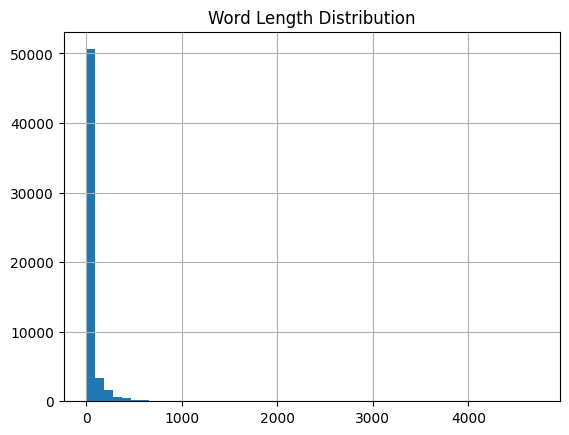

In [9]:
train_df['word_len'].hist(bins=50)
plt.title("Word Length Distribution")
plt.show()

<h3>Checking for Duplicates, Missing, Dirty Data</h3>

In [ ]:
train_df.duplicated(subset=["prompt"]).sum()
# 5743 Rows missing, optional drop below:
# train_df.drop_duplicates(subset=["prompt"])

np.int64(5743)

In [11]:
train_df.isnull().sum()

id                0
model_a           0
model_b           0
prompt            0
response_a        0
response_b        0
winner_model_a    0
winner_model_b    0
winner_tie        0
char_len          0
word_len          0
dtype: int64

In [13]:
(train_df['prompt'].str.strip() == "").sum()

np.int64(0)

<h3>Training</h3>

In [15]:
train_df["label"] = np.argmax(
    train_df[["winner_model_a", "winner_model_b", "winner_tie"]].values,
    axis=1
)

train_df["label"].value_counts()

label
0    20064
1    19652
2    17761
Name: count, dtype: int64

In [17]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [18]:
train_df["fold"] = -1

for fold, (train_idx, val_idx) in enumerate(
    skf.split(train_df, train_df["label"])
):
    train_df.loc[val_idx, "fold"] = fold

In [19]:
train_df["fold"].value_counts()

fold
0    11496
1    11496
4    11495
3    11495
2    11495
Name: count, dtype: int64

In [ ]:
for fold in range(5):
    print(f"===== FOLD {fold} =====")

    train_data = train_df[train_df["fold"] != fold]
    val_data = train_df[train_df["fold"] == fold]

    # Split features and target
    X_train = train_data["prompt"]